# Sieci Neuronowe Oparte na Fizyce - Physics Informed Neural Networks (PINNs)

## Autor: Łukasz Grzegrzółka

### Warszawa, 12.06.2026

<a href="https://colab.research.google.com/github/lukasz23g/Interactive_Machine_Learning_2026/blob/main/PINNs_presentation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## 1. Wprowadzenie: Od Oświecenia do Ery Big Data



### Tradycyjny Model Nauki - Sprzężenie Zwrotne
Od czasów oświecenia rozwój nauki opierał się na nieustannej symbiozie dwóch filarów, które wzajemnie się uzupełniały i napędzały swój postęp:

$$\Large\textbf{Dane Eksperymentalne} \quad \Longleftrightarrow \quad \textbf{Przewidywania Teoretyczne}$$

---

### Rewolucja Big Data - Podejście "Brute Force"
Wraz z gwałtownym rozwojem komputerów i wzrostem ich mocy obliczeniowej, punkt ciężkości przesunął się drastycznie w stronę danych.

* **Potęga ML:** $$\textbf{Miliardy parametrów} \quad \implies \quad \textbf{Aproksymacja dowolnej złożoności}:~X \rightarrow f(X)$$

* **Modelowanie bez teorii:**

$$\textbf{Masowa analiza danych} \longrightarrow\ \textbf{Skuteczne modelowanie} \longrightarrow \textbf{Zależności poza zasięgiem teorii}$$

* **Zmiana priorytetów:**  $$\textbf{Szybka odpowiedź} \quad \gg \quad \textit{Głębokie zrozumienie procesu fizycznego}$$

<div align="center">
    <img src="https://benmoseley.blog/wp-content/uploads/2021/08/nn.png" width="60%" alt="Neural Network">
</div>

---

### Wady Podejścia Czysto Statystycznego
Poleganie wyłącznie na danych (Black-Box ML) rodzi poważne konsekwencje w naukach inżynieryjnych i fizycznych:

* **Głód danych:** Skuteczny trening wymaga ogromnej liczby perfekcyjnie przygotowanych i zbalansowanych danych.

* **Problem "czarnej skrzynki" i halucynacje:**

$$\text{Brak dokładnego zrozumienia modelu} \quad \implies \quad \text{Ryzyko halucynacji i kosztownych błędów}$$


* **Przeuczenie (Overfitting)**

* **Brak generalizacji i ekstrapolacji**

* **Brak uwzględnienia fundamentalnej wiedzy o właściwościach modelowanego zjawiska**

<div align="center">
    <img src="https://benmoseley.blog/wp-content/uploads/2021/08/nn.gif" width="60%" alt="Neural Network not generalizes">
</div>

---

## 📌 Pytanie Kluczowe:
> ### Czy możemy w jakiś inny sposób zasugerować sieci właściwą ścieżkę i zachowanie w rejonach, dla których nie posiadamy żadnych danych treningowych lub posiadamy ich za mało?

<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/New_path_search.png" width="80%" alt="Neural Network">
</div>


$$\Huge \textbf{Tak!} \quad \Longrightarrow \quad \text{ Idea sieci } \color{#2563eb}{\textbf{PINNs}}$$

<div align="center">
    <img src="https://www.mathworks.com/discovery/physics-informed-neural-networks/_jcr_content/mainParsys/columns/e4219b80-580a-4cc2-a14e-84b7087007c5/image.adapt.full.medium.png/1779261053430.png" width="80%" alt="New paths">
</div>

### Modyfikacja Funkcji Straty
Zamiast uczyć sieć fizyki poprzez pokazywanie jej milionów przykładów, możemy **zasugerować** jej poprawne zachowanie. Robimy to poprzez matematyczne rozszerzenie kryterium sukcesu (funkcji straty).

* **Tradycyjne podejście:** Sieć optymalizuje wyłącznie błąd dopasowania do znanych etykiet.

* **Podejście Informed:** Do funkcji straty wprowadzamy nowy, dodatkowy człon - karę za łamanie uniwersalnych praw fizyki.

$$\Large \mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \mathcal{L}_{\text{physics}}$$

<br>

---

### Co to oznacza w praktyce?

* **$\mathcal{L}_{\text{data}}$ (Komponent Statystyczny):** Klasyczny loss sieci neuronowych.

$$\mathcal{L}_{\text{data}} \longrightarrow \text{Minimalizacja błędu na punktach pomiarowych}$$

* **$\mathcal{L}_{\text{physics}}$ (Komponent Teoretyczny):** czy w dowolnym punkcie przestrzeni sieć nie generuje rozwiązań niefizycznych.

$$\mathcal{L}_{\text{physics}} \longrightarrow \text{Wymuszenie uniwersalnych praw przyrody (np. zachowania energii/masy)}$$

<br>

<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/NN_vs_PINN_comparison.png" width="50%" alt="NN vs PINN">
</div>

---

## 2. Przykład tłumionego oscylatora harmonicznego

> ### Jak zrealizować koncepcję PINNs w kodzie i zmusić algorytm do liczenia fizycznych pochodnych?

<div style="display: flex; justify-content: space-around; align-items: center;">
    <div style="text-align: center; width: 29%;">
        <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/Damped_oscillator_oil.png" style="width: 95%;">
        <p>Tłumiony oscylator harmoniczny - przykład realizacji</p>
    </div>
    <div style="text-align: center; height: 44%;">
        <img src="https://benmoseley.blog/wp-content/uploads/2021/08/oscillator.gif" style="width: 95%;">
        <p>Tłumiony oscylator harmoniczny - animacja</p>
    </div>
</div>

## Rozwiązanie analityczne modelu oscylatora harmonicznego w zależności od masy drgajacej $m$, wartości parametu tłumienia $\mu$ i stałej sprężystości $k$

### Równanie oscylatora harmonicznego:

$$
m \dfrac{d^2 u}{d t^2} (t) + \mu \dfrac{d u}{d t} (t) + ku(t) = 0~,
$$

gdzie $m$ to drgajaca masa, $\mu$ to siłą tłumienia i $k$ to stała sprężystości.

---

###  Klasy rozwiązań równania ruchu

Zachowanie układu zależy bezpośrednio od relacji pomiędzy **siłą tłumienia** a **siłą sprężystości** (oraz od warunków początkowych). Na tej podstawie wyróżniamy trzy klasy rozwiązań:

* **Tłumienie słabe (podkrytyczne):** Układ wykonuje oscylacje o stopniowo malejącej amplitudzie. Siła sprężystości dominuje nad oporem.

* **Tłumienie krytyczne:** Układ wraca do położenia równowagi w najkrótszym możliwym czasie, nie wykonując ani jednego pełnego wahnięcia.

* **Tłumienie silne (nadkrytyczne):** Opór ośrodka jest tak duży, że układ bardzo powoli i "wielkim wysiłkiem" wraca do stanu spoczynku.

In [5]:
import numpy as np
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider

# ⚠️ KLUCZOWE DLA GOOGLE COLAB:
# Ta linijka odblokowuje komunikację między ipywidgets a silnikiem JS Plotly
from google.colab import output
output.enable_custom_widget_manager()

def damped_oscillator_solution(m, mu, k, u0, v0, t):
    omega0 = np.sqrt(k / m)
    zeta = mu / (2 * np.sqrt(m * k))

    if zeta < 1:
        omega_d = omega0 * np.sqrt(1 - zeta**2)
        A = u0
        B = (v0 + zeta * omega0 * u0) / omega_d
        u = np.exp(-zeta * omega0 * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
        regime = "Słabe tłumienie (ζ < 1)"
    elif np.isclose(zeta, 1.0, atol=1e-3):
        A = u0
        B = v0 + omega0 * u0
        u = (A + B * t) * np.exp(-omega0 * t)
        regime = "Tłumienie krytyczne (ζ ≈ 1)"
    else:
        disc = mu**2 - 4 * m * k
        r1 = (-mu + np.sqrt(disc)) / (2 * m)
        r2 = (-mu - np.sqrt(disc)) / (2 * m)
        C2 = (v0 - r1 * u0) / (r2 - r1)
        C1 = u0 - C2
        u = C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t)
        regime = "Silne tłumienie (ζ > 1)"

    return u, zeta, omega0, regime

def plot_damped_oscillator_plotly(m, mu, k, u0, v0):
    t = np.linspace(0, 20, 1000)
    u, zeta, omega0, regime = damped_oscillator_solution(m, mu, k, u0, v0, t)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t, y=u, mode="lines", name="u(t)", line=dict(width=3, color='#1f77b4')))

    fig.update_layout(
        title=f"<b>Oscylator tłumiony</b><br>ζ = {zeta:.3f}, ω₀ = {omega0:.3f} | {regime}",
        xaxis_title="Czas (t)",
        yaxis_title="Wychylenie u(t)",
        width=1000,   # Zmniejszyłem lekko szerokość z 1400 do 1000, żeby wykres idealnie mieścił się w oknie Colaba
        height=500,
        template="plotly_white",
        yaxis=dict(range=[-2.2, 2.2]), # Dostosowałem zakres, by współgrał z Twoim poprzednim wykresem w matplotlib
        margin=dict(l=40, r=40, t=80, b=40)
    )

    # Renderujemy wykres za pomocą dedykowanego widoku dla notebooków
    fig.show(renderer="colab")

# Uruchomienie interakcji
interact(
    plot_damped_oscillator_plotly,
    m=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.05, description='m'),
    mu=FloatSlider(value=0.5, min=0.0, max=4.0, step=0.05, description='μ'),
    k=FloatSlider(value=4.0, min=0.1, max=10.0, step=0.05, description='k'),
    u0=FloatSlider(value=1.5, min=-2.0, max=2.0, step=0.01, description='u(0)'),
    v0=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.05, description="u'(0)")
)

interactive(children=(FloatSlider(value=1.0, description='m', max=5.0, min=0.1, step=0.05), FloatSlider(value=…

<function __main__.plot_damped_oscillator_plotly(m, mu, k, u0, v0)>

### Przypadek słabego tłumienia

My skupimy się na najbardziej dynamicznym przypadku tłumienia słabego. Matematycznie takie rozwiązanie obowiązuje, gdy:

$$
\delta < \omega_0~,~~~~~\mathrm{gdzie}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$

W dalszej części założymy również stałe warunki początkowe:

$$
u(t=0) = 1~~,~~\dfrac{d u}{d t}(t=0) = 0~.
$$

W takim przypadku dokładne rozwiązanie równania oscylatora ma postać:

$$
u(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{gdzie}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$

Oznacza to, że oscylator wykonuje drgania o amplitudzie zanikajacej wykładniczo w czasie jak $e^{-\delta t}$, oraz o częstotliwości zmniejszonej względem częstotliwości własnej masy na sprężynie (bez tłumienia), wynoszącej $\omega=\sqrt{\omega_0^2 - \delta^2}$.


## 3. Jak zmusić sieć do nauki fizyki?

---

### Konwencjonalne dane a punkty kolokacji
W klasycznym uczeniu maszynowym dopasowujemy model do sztywnych par wejście-wyjście. W PINNs wprowadzamy dwa niezależne źródła informacji:

* **Punkty obserwacyjne ($t_i$):** rzeczywiste punkty pomiarowe.

* **Punkty kolokacji ($t_j$):** dowolnie gęsta siatka punktów w przestrzeni wejściowej, w których sprawdzamy fizyczność modelu.

---

### Pełna postać funkcji straty dla oscylatora
Dla naszego tłumionego oscylatora harmonicznego ogólna funkcja straty przyjmuje następującą postać:

$$\mathcal{L}(\theta)= \underbrace{\frac{1}{N} \sum^{N}_{i} \left(  u_{\mathrm{PINN}}(t_{i}; \theta) - u_{\mathrm{true}}(t_{i})  \right)^2}_{\text{Zgodność z obserwacjami (Dane)}} + \underbrace{\frac{\lambda}{M} \sum^{M}_{j} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] u_{\mathrm{PINN}}(t_{j};\theta)  \right)^2}_{\text{Fizyczność rozwiązania (Równanie Różniczkowe)}}$$

<br>

<div align="center">
    <img src="https://benmoseley.blog/wp-content/uploads/2021/08/pinn.png" width="75%" alt="Schemat sieci PINN z modułem różniczkowania">
</div>
<br>

> ⚡ **Klucz technologiczny: Autograd**
> Obliczenie wyższych pochodnych funkcji wyjściowej ($u$) względem wejścia ($t$) jest możliwe dzięki silnikowi **automatycznego różniczkowania**. Pozwala to na jawną ewaluację i łatwe dodanie członu fizycznego do funkcji straty.

---

### 💡 Ciekawe obserwacje i korzyści z nowej funkcji straty

* **Naturalna regularyzacja:** fizyka blokuje model przed dopasowaniem się do szumu (overfittingiem).

* **Bezpieczna ekstrapolacja:** prawa fizyki blokują halucynacje modelu.

* **Małe zbiory danych:** minimalna wymagana liczba pomiarów - brakujące informacje model pozyskuje bezpośrednio z fizyki układu.

---

## Pytanie: A co jeśli danych treningowych nie ma WCALE?
Czy model zadziała, mając wyłącznie człon fizyczny? **Tak, ale pod pewnymi warunkami.**

Ogólna postać rozwiązania równania zawiera stałe (amplitudę $A$ i przesunięcie fazowe $\phi$). Zmiana tych parametrów ustala warunki początkowe. Aby wybrać konkretną postać rozwiązania, musimy podać modelowi punkty brzegowe oraz znać stałe fizyczne ($m, \mu, k$).

$$\text{Brak danych treningowych} \quad \implies \quad \text{Wymagane jawne warunki brzegowe / początkowe}$$

### Założenia początkowe:
Aby sieć zadziałała bez danych treningowych, definiujemy problem za pomocą konkretnych warunków brzegowych i fizycznych:

* **Położenie początkowe:** $\rightarrow u(0) = 1$.
* **Prędkość początkowa:** $\rightarrow u'(0) = 0$.
* **Parametry oscylatora:** $\delta=2$, $\omega_0=20$

Szukamy rozwiązania na przedziale $t \in [0,1]$.

W efekcie funkcja straty redukuje się do postaci **czystego solvera** równania różniczkowego:

$$\mathcal{L}(\theta)= \underbrace{(u_{\mathrm{PINN}}(t=0;\theta) - 1)^2}_{\text{Warunek położenia początkowego}} + \lambda_1 \underbrace{\left(\frac{d\,u_{\mathrm{PINN}}}{dt}(t=0;\theta) - 0\right)^2}_{\text{Warunek prędkości początkowej}} + \underbrace{\frac{\lambda_2}{N} \sum^{N}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] u_{\mathrm{PINN}}(t_{i};\theta)  \right)^2}_{\text{Spełnienie równania różniczkowego}}$$

---

## 🛠️ Część Praktyczna: Tutorial PyTorch

Najpierw definiujemy funkcje pomocnicze i w pełni połączoną sieć neuronową.

Źródło: https://github.com/benmoseley/harmonic-oscillator-pinn-workshop/blob/main/PINN_intro_workshop.ipynb

In [ ]:
import torch
import torch.nn as nn

def exact_solution(d, w0, t):
    "Defines the analytical solution to the under-damped harmonic oscillator problem above."
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*t)
    exp = torch.exp(-d*t)
    u = exp*2*A*cos
    return u

class FCN(nn.Module):
    "Defines a standard fully-connected network in PyTorch"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()

        ###############
        activation = nn.Tanh     # tanh jako funkcja aktywacji -> DLACZEGO?
        ##############

        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

### Dlaczego jako funkcję aktywacji stosujemy tanh, a nie po prostu ReLU?

<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/Tanh_vs_relu.png" width="60%" alt="Tanh_vs_relu">
</div>

### Trening sieci i rozwiązanie równania różniczkowego

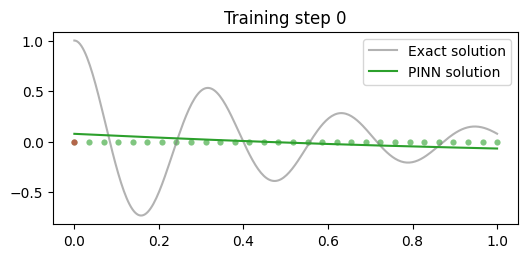

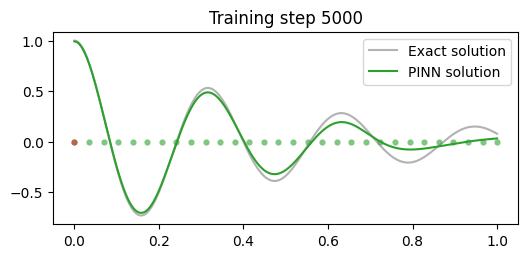

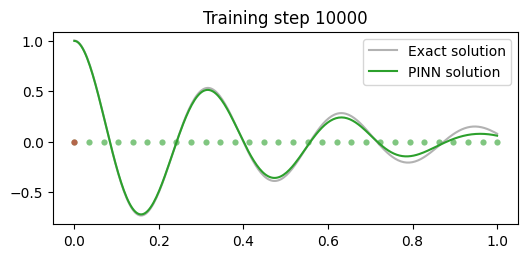

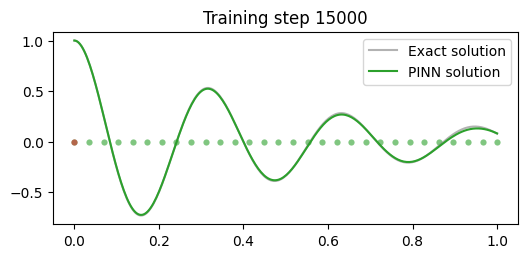

In [ ]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

# define boundary points, for the boundary loss
t_boundary = torch.tensor(0.).view(-1,1).requires_grad_(True)           #!!!!!!!!

# define training points over the entire domain, for the physics loss
t_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)      #!!!!!!!!

# train the PINN
d, w0 = 2, 20
mu, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)
for i in range(15001):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters:
    lambda1, lambda2 = 1e-1, 1e-4

    # compute boundary loss
    u = pinn(t_boundary)        # przewidywane położenie początkowe w t=0, u(0)
    loss1 = (torch.squeeze(u) - 1)**2          # L_1 - czy oscylator startuje z u(0) = 1
    dudt = torch.autograd.grad(u, t_boundary, torch.ones_like(u), create_graph=True)[0]      # przewidywana prędkość w t=0, u'(0)
    loss2 = (torch.squeeze(dudt) - 0)**2        # L_2 - czy oscylator startuje w spoczynku: u'(0) = 0

    # compute physics loss
    u = pinn(t_physics)         #przewidywane położenia w różnych punktach
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]      #prędkości w tych punktach
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]      #przyspieszenia w tych punktach
    loss3 = torch.mean((d2udt2 + mu*dudt + k*u)**2)           # czy przewidywania sieci spełniają równanie różniczkowe?

    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2 + lambda2*loss3        # pełna funkcja straty z wagami lambda_1 i lambda_2
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if i % 5000 == 0:
        #print(u.abs().mean().item(), dudt.abs().mean().item(), d2udt2.abs().mean().item())
        u = pinn(t_test).detach()
        plt.figure(figsize=(6, 2.5))
        plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:green", alpha=0.6)
        plt.scatter(t_boundary.detach()[:,0],
                    torch.zeros_like(t_boundary)[:,0], s=20, lw=0, color="tab:red", alpha=0.6)
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()

## 4. Problem Odwrotny (Inverse Problem): Estymacja Parametrów Fizycznych

### Jak połączyć niekompletną wiedzę teoretyczną z zaszumionymi pomiarami?

---

### Nowe wyzwanie: Nieznany parametr układu
W praktyce inżynierskiej rzadko znamy idealne wartości wszystkich stałych fizycznych. Często dysponujemy pewnymi pomiarami, ale nasza wiedza o układzie jest niepełna.

* **Założenie:** Mamy kilkanaście punktów pomiarowych obarczonych błędem (szum numeryczny).
* **Niewiadoma:** Nie znamy dokładnej wartości współczynników układu, np. tłumienia $\mu$.

---

### Funkcja straty jako narzędzie kompromisu
Skoro nie znamy $\mu$, nie możemy bezpośrednio użyć równania jako sztywnego ograniczenia. Zamiast tego traktujemy $\mu$ jako **zmienną decyzyjną**, którą sieć optymalizuje *jednocześnie* z wagami sieci $\theta$.

$$\mathcal{L}(\theta, \mu)=  \underbrace{\frac{1}{N} \sum^{N}_{j} \left( u_{\mathrm{PINN}}(t_{j};\theta) - u_{\mathrm{obs}}(t_{j}) \right)^2}_{\text{Zgodność z zaszumionymi pomiarami}} + \underbrace{\frac{\lambda}{M} \sum^{M}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] u_{\mathrm{PINN}}(t_{i};\theta)  \right)^2}_{\text{Spełnienie prawa fizyki (ze zmiennym } \mu)}$$


> **Ważna zmiana strukturalna:**
> W tej konfiguracji całkowicie rezygnujemy z jawnych członów warunków brzegowych ($u(0), u'(0)$). Ich rolę w zakotwiczeniu rozwiązania przejęły rozproszone w czasie dane treningowe (obserwacje).

---

### Dwa cele podczas jednej pętli treningowej
Zmuszamy sieć do jednoczesnego wykonywania dwóch zadań:

1. **Regresji statystycznej:** Dopasowania gładkiej krzywej do zaszumionych punktów.

2. **Odkrywania fizyki:** Znalezienia takiej stałej $\mu$, dla której lewa strona równania różniczkowego jest jak najbliższa zeru.

## Implementacja w PyTorch

### Najpierw generujemy zaszumione dane treningowe

True value of mu: 4


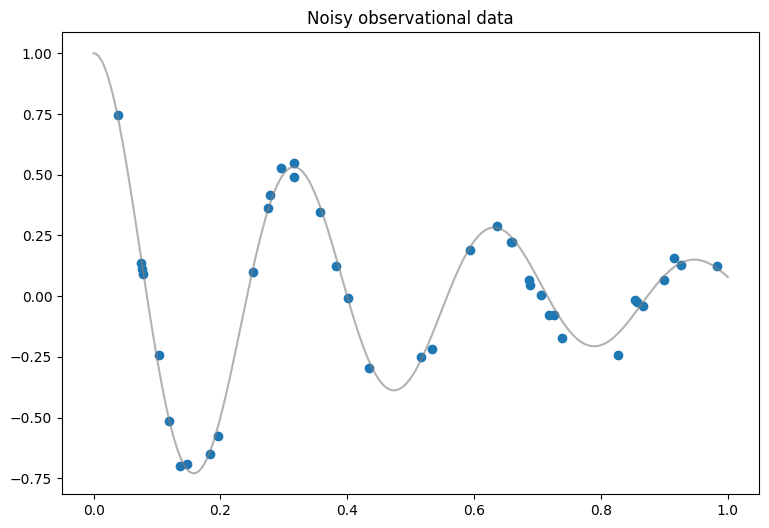

In [ ]:
# first, create some noisy observational data
torch.manual_seed(123)
d, w0 = 2, 20
print(f"True value of mu: {2*d}")
t_obs = torch.rand(40).view(-1,1)
u_obs = exact_solution(d, w0, t_obs) + 0.04*torch.randn_like(t_obs)

plt.figure(figsize=(9, 6))
plt.title("Noisy observational data")
plt.scatter(t_obs[:,0], u_obs[:,0])
t_test, u_exact = torch.linspace(0,1,300).view(-1,1), exact_solution(d, w0, t_test)
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.show()

### Nastęnie inicjujemy sieć neuronową z odpowiednio zdefiniowaną funkcją straty:

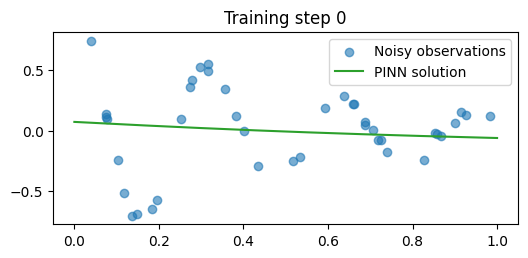

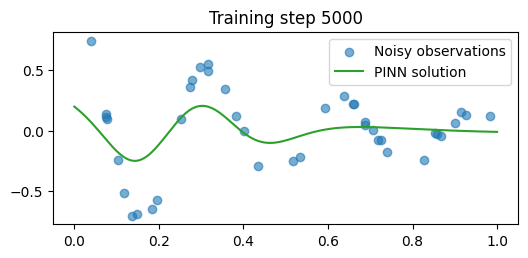

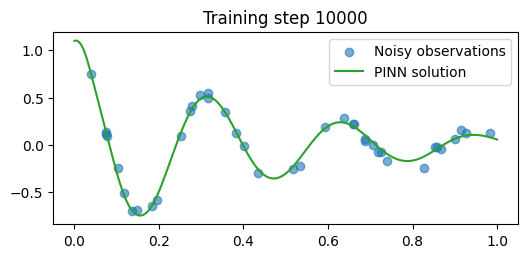

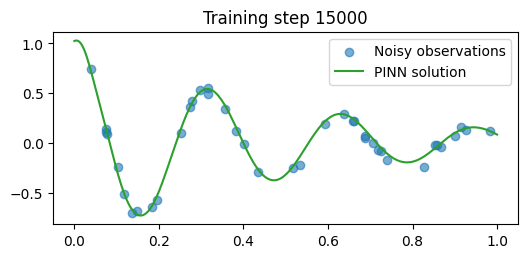

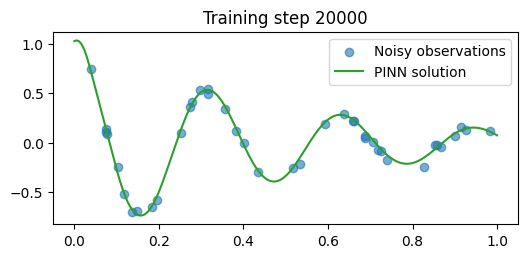

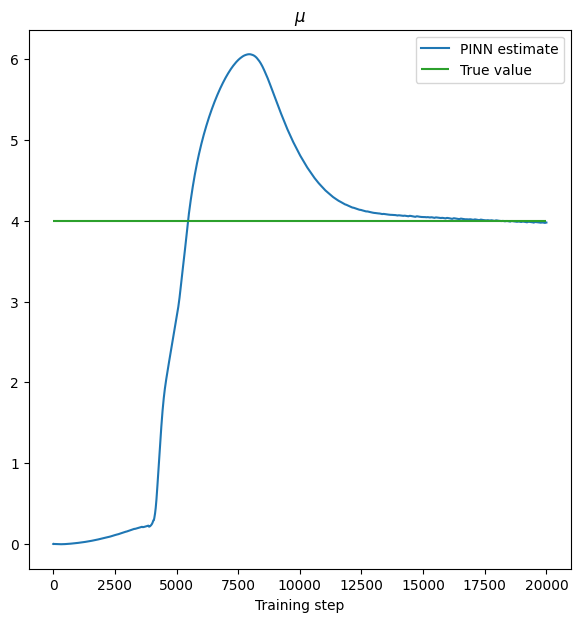

In [ ]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

# define training points over the entire domain, for the physics loss
t_physics = torch.linspace(0, 1, 30).view(-1,1).requires_grad_(True)

# train the PINN
d, w0 = 2, 20       #te same parametry oscylatora
_, k = 2*d, w0**2   #nie zapisujemy wartości mu

# treat mu as a learnable parameter
mu = torch.nn.Parameter(torch.zeros(1, requires_grad=True))     #traktujemy mu jako parametr do uczenia
mus = []

# add mu to the optimiser
optimiser = torch.optim.Adam(list(pinn.parameters())+[mu], lr=1e-3)
for i in range(20001):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters:
    lambda1 = 1e-4

    # compute data loss
    u = pinn(t_obs)         #przewidywania sieci w punktach pomiarowych
    loss1 = torch.mean((u - u_obs)**2)      # porównanie z obserwacjami

    # compute physics loss
    u = pinn(t_physics)         #przewidywane położenia w różnych punktach
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]      #prędkości w tych punktach
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]      #przyspieszenia w tych punktach
    loss2 = torch.mean((d2udt2 + mu*dudt + k*u)**2)           # czy przewidywania sieci spełniają równanie różniczkowe?


    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2        #liczymy łączną stratę
    loss.backward()
    optimiser.step()

    # record mu value
    mus.append(mu.item())       # zapisujemy wartość mu

    # plot the result as training progresses
    if i % 5000 == 0:
        u = pinn(t_test).detach()
        plt.figure(figsize=(6, 2.5))
        plt.scatter(t_obs[:,0], u_obs[:,0], label="Noisy observations", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()

plt.figure(figsize=(7, 7))
plt.title("$\\mu$")
plt.plot(mus, label="PINN estimate")
plt.hlines(2*d, 0, len(mus), label="True value", color="tab:green")
plt.legend()
plt.xlabel("Training step")
plt.show()

### Sieć skutecznie zrealizowała oba cele:

* **Identyfikacja fizyki:** parametr $\mu$ zbiegł z początkowego punktu 0.0 i ustabilizował się na poprawnej fizycznie wartości.

* **Odporność na szum:** wbudowana regularyzacja wynikająca z członu $\mathcal{L}_{\text{physics}}$ zapobiegła przeuczeniu.

---

## 5. Wyzwania i Ograniczenia PINNs (Failure Modes)


### 1. Koszt obliczeniowy i alternatywy klasyczne
Mimo swojej elegancji, PINNs nie zawsze są optymalnym wyborem do każdego problemu inżynierskiego.

* **Złożoność pętli:** Wielokrotne obliczanie wyższych pochodnych przez Autograd w każdej iteracji jest kosztowne obliczeniowo i czasochłonne.

* **Klasyczne alternatywy:** Dla standardowych, dobrze opisanych geometrii, tradycyjne metody dyskretne, takie jak **Metoda Elementów Skończonych (FEM)** lub **Metoda Różnic Skończonych (FDM)** będą wciąż **szybsze i pewniejsze** niż trenowanie sieci neuronowej od zera.


### 2. Problem wysokich częstotliwości (Sztywność Gradientowa)
PINNs doskonale symulują zjawiska o łagodnym przebiegu, ale zawodzą przy gwałtownych oscylacjach.

W pierwszym przykładzie (czysty solver) zwiększymy częstotliwość własną oscylatora:

$$\omega_0 = 20 \quad \longrightarrow \quad \omega_0 = 80$$

model całkowicie traci zbieżność i generuje losowe, błędne wyniki!

**Dlaczego tak się dzieje?**
* **Niewypukły krajobraz straty:** Człon fizyczny w $\mathcal{L}_{\text{physics}}$ tworzy skomplikowaną powierzchnię błędu z tysiącami maksimów i minimów lokalnych.

* **Dominacja pochodnych:** Przy wysokich częstotliwościach wyższe pochodne ($u''$) rosną nieproporcjonalnie szybko. Optymalizator (np. Adam) zostaje natychmiast uwięziony w losowym minimum lokalnym, z którego nie potrafi się wydostać.

<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/PINNs_loss_landscape.png" width="90%" alt="Krajobraz funkcji starty w modelowaniu konwekcji">
</div>


### 3. Brak uniwersalnych standardów

> Każdy wygenerowany przez sieć wynik musi być bezwzględnie i krytycznie przeanalizowany pod kątem fizycznym, ponieważ algorytm może zbiec do rozwiązania, które jest błędne i tylko lokalnie minimalizuje stratę.

---

## Jak radzić sobie z brakiem zbieżności?

Jeśli sieć nie potrafi odnaleźć rozwiązania, w literaturze omawia się trzy główne podejścia:

### 1. Curriculum Learning (Stopniowanie trudności fizycznej)
Zamiast rzucać sieć na głęboką wodę ($\omega_0 = 80$), stosujemy strategię małych kroków:
1. Trenujemy model dla niskiej, prostej częstotliwości ($\omega_0 = 5$).

2. Po osiągnięciu zbieżności, delikatnie zwiększamy parametr i wznawiamy trening, **adaptując dotychczasowe wagi (transfer learning)**, zamiast losowej inicjalizacji.

<br>
<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/Curriculum_learning_table.png" width="60%" alt="Krajobraz funkcji starty w modelowaniu konwekcji">
</div>

### 2. Rozszerzanie dziedziny pomiarowej (Domain Extension)
Stopniowo zwiększamy przestrzeń danych wejściowych $X$ (lub domeny czasowej $t$):

1. Model najpierw uczy się zachowania układu w bardzo krótkim przedziale czasu,

2. Następnie sukcesywnie "dokleja" nowe rejony, traktując poprzednie przewidywania jako warunki brzegowe.

<br>
<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/PINNs_seq2seq_idea.png" width="60%" alt="Krajobraz funkcji starty w modelowaniu konwekcji">
</div>

<div align="center">
    <img src="https://raw.githubusercontent.com/lukasz23g/Interactive_Machine_Learning_2026/refs/heads/main/PINNs_presentation/PINNs_seq2seq_example.png" width="60%" alt="Krajobraz funkcji starty w modelowaniu konwekcji">
</div>


### 3. Wstrzykiwanie fizycznej intuicji (Ansatz strukturalny)

Jeśli mamy silne przypuszczenia co do natury rozwiązania, możemy narzucić sieci odpowiednią formę matematyczną (tzw. *ansatz*).

**Przykład oscylatora harmonicznego przy dużej częstotliwości**

Zamiast uczyć sieć czystej funkcji $u(t)$, definiujemy jej wyjście jako iloczyn:

$$\hat u(t; \theta, \alpha, \beta) = u_{\mathrm{PINN}}(t;\theta) \cdot \sin (\alpha t + \beta)$$

* **Gdzie:** $\alpha$ oraz $\beta$ to dodatkowe, pojedyncze parametry podlegające optymalizacji.

* **Efekt:** Drastycznie upraszcza to zadanie stojące przed siecią neuronową.

### Oryginalne rozwiązanie:

$$
u(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))
$$

**Sieć musi nauczyć się tylko członu eksponencjalnego oraz trzech parametrów!**


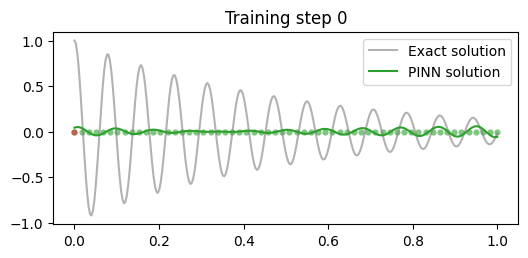

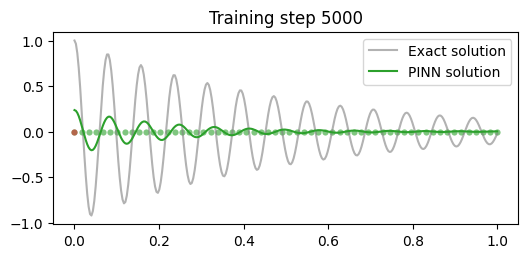

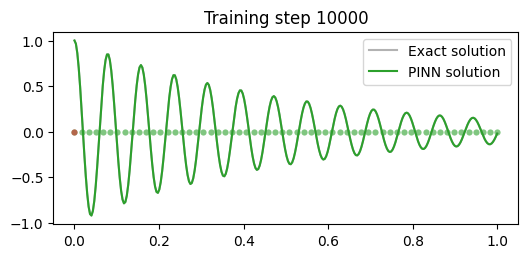

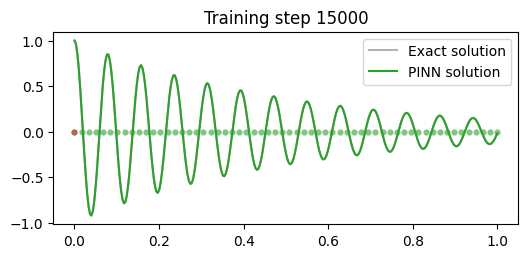

In [ ]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

# define additional a,b learnable parameters in the ansatz
a = torch.nn.Parameter(70*torch.ones(1, requires_grad=True))
b = torch.nn.Parameter(torch.ones(1, requires_grad=True))

# define boundary points, for the boundary loss
t_boundary = torch.tensor(0.).view(-1,1).requires_grad_(True)

# define training points over the entire domain, for the physics loss
t_physics = torch.linspace(0,1,60).view(-1,1).requires_grad_(True)

# train the PINN
d, w0 = 2, 80# note w0 is higher!
mu, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)
# add a,b to the optimiser
optimiser = torch.optim.Adam(list(pinn.parameters())+[a,b],lr=1e-3)
for i in range(15001):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters:
    lambda1, lambda2 = 1e-1, 1e-4

    # compute boundary loss
    u = pinn(t_boundary)*torch.sin(a*t_boundary+b)
    loss1 = (torch.squeeze(u) - 1)**2
    dudt = torch.autograd.grad(u, t_boundary, torch.ones_like(u), create_graph=True)[0]
    loss2 = (torch.squeeze(dudt) - 0)**2

    # compute physics loss
    u = pinn(t_physics)*torch.sin(a*t_physics+b)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]
    loss3 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2 + lambda2*loss3
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if i % 5000 == 0:
        #print(u.abs().mean().item(), dudt.abs().mean().item(), d2udt2.abs().mean().item())
        u = (pinn(t_test)*torch.sin(a*t_test+b)).detach()
        plt.figure(figsize=(6,2.5))
        plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:green", alpha=0.6)
        plt.scatter(t_boundary.detach()[:,0],
                    torch.zeros_like(t_boundary)[:,0], s=20, lw=0, color="tab:red", alpha=0.6)
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()

## 6. Podsumowanie


* 🧠 **Synergia, nie zastępstwo:** PINNs nie eliminują fizyki teoretycznej ani metod numerycznych (FEM/FDM). Są mostem łączącym czystą statystykę Big Data z uniwersalnymi prawami przyrody.

* 🛠️ **Potęga w ograniczeniach:** Wprowadzenie wiedzy fizycznej ($\mathcal{L}_{\text{physics}}$) działa jak naturalna regularyzacja. Pozwala na stabilną pracę przy **braku danych** pomiarowych oraz chroni model przed przeuczeniem i halucynacjami.

* 🔍 **Rozwiązywanie i odkrywanie:** Ten sam paradygmat pozwala zarówno zastąpić klasyczne solwery (problem prosty), jak i automatycznie **identyfikować nieznane stałe układu** na podstawie zaszumionych eksperymentów (problem odwrotny).

* ⚡ **Wyzwanie optymalizacyjne:** Krajobraz funkcji straty w PINNs jest z natury niewypukły. Problemy wysokich częstotliwości wymagają zaawansowanych strategii (Curriculum Learning, Ansatz), a wynik końcowy zawsze wymaga krytycznej oceny inżynierskiej.

---

##  Źródła


### Wykłady i materiały wideo
* **[Wykład]** Steve Brunton – *Physics Informed Neural Networks (PINNs)* [Nagranie YouTube](https://youtu.be/-zrY7P2dVC4?si=lf43UVTO3USsHDv4) – znakomite wprowadzenie wideo do matematycznych podstaw i intuicji stojących za PINNs.
* **[Wykład]** Ben Moseley – *Physics-Informed Neural Networks (PINN) - an introductory crash-course* [Nagranie YouTube](https://youtu.be/G_hIppUWcsc?si=JcExGRbDVfRNjUr9) – praktyczne omówienie architektury i implementacji kodu krok po kroku w PyTorch.


### Artykuły blogowe i materiały warsztatowe
* **[Workshop & Kod]** Ben Moseley – *Harmonic Oscillator PINN Workshop (PyTorch)* [Repozytorium GitHub](https://github.com/benmoseley/harmonic-oscillator-pinn-workshop/blob/main/PINN_intro_workshop.ipynb) – bezpośrednie źródło wykorzystanego w prezentacji samouczka.
* **[Wprowadzenie]** Ben Moseley – *So, what is a physics-informed neural network?* [Artykuł na blogu autora](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/) – przystępne omówienie intuicji stojących za paradygmatem PINN.
* **[Przegląd]** MathWorks Discovery – *Physics-Informed Neural Networks (PINNs)* [Dokumentacja MathWorks](https://www.mathworks.com/discovery/physics-informed-neural-networks.html) – przekrojowe omówienie zastosowań PINNs w inżynierii i modelowaniu.



### Publikacje naukowe
* **[Fundamentalna Praca]** Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations.* Journal of Computational Physics, 378, 686-707. - praca, która zapoczątkowała i sformalizowała współczesne podejście do PINNs.
* **[Analiza Błędów]** Krishnapriyan, A. S., Gholami, A., Zhe, S., Kirby, R. M., & Mahoney, M. W. (2021). *Characterizing possible failure modes in physics-informed neural networks.* Advances in Neural Information Processing Systems (NeurIPS 2021). - źródło omawiające problemy zbiegłości, niewypukły krajobraz straty oraz sztywność gradientową przy wysokich częstotliwościach.
* **[Zastosowanie Specjalistyczne]** Moseley, B., Markham, A., & Nissen-Meyer, T. (2020). *Solving the wave equation with physics-informed deep learning.* arXiv preprint arXiv:2006.11894. - studium przypadku pokazujące ograniczenia i zaawansowane strategie uczenia, takie jak Curriculum Learning, w zagadnieniach silnie oscylacyjnych.